# Telecom Customer Churn

**Aim**: The aim of this notebook is to predict which customer will churn so that we can provide them with offers in order to retain them



## Make Imports

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, recall_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LogisticRegression

## Load the dataset

In [3]:
df = pd.read_csv("Data/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## EDA

Churn
No     5174
Yes    1869
Name: count, dtype: int64


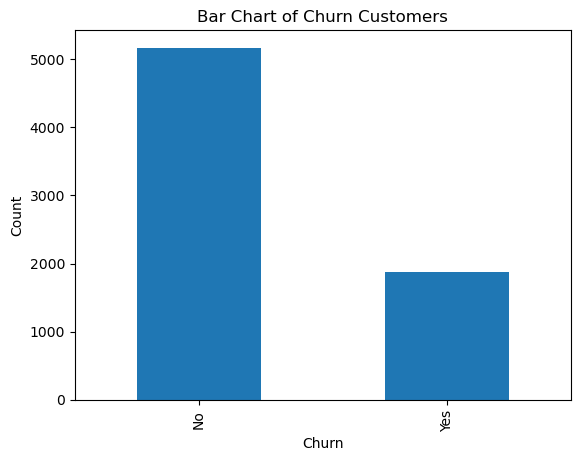

In [6]:
counts = df['Churn'].value_counts()
print(counts)
counts.plot(kind='bar')
plt.title('Bar Chart of Churn Customers')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show();


In [7]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [8]:
df.groupby('Contract')['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

* From the above two cells we can see, that if a person has month to month contract they are likely to churn
* But, inside contract, if a person has high tenure, they are less likely to churn
* Here, tenure refines the prediction of contract
* This is known as **Feature Interrelation**

In [9]:
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[0, 6, 12, 24, 100],
    labels=["0-6", "6-12", "12-24", "24+"],
    right=False
)
df['tenure_bucket'].value_counts()

tenure_bucket
24+      3927
0-6      1371
12-24    1047
6-12      698
Name: count, dtype: int64

In [10]:
df.groupby('tenure_bucket', observed=True)['Churn'].value_counts()

tenure_bucket  Churn
0-6            Yes       744
               No        627
6-12           No        443
               Yes       255
12-24          No        738
               Yes       309
24+            No       3366
               Yes       561
Name: count, dtype: int64

* If customer tenure is 0-6, they are likely to churn (744) = 54.2% i.e. **MASSIVE**
* For 6-12, they are less likely to churn i.e. 36.5%
* For 12-24, same like above i.e. 29.5%
* For 24+, it is very less i.e. 14.2%
* Tenure has strong, smooth, decreasing relationship with churn.

## Data Preprocessing


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
tenure_bucket       0
dtype: int64

### Dropping Redundant Columns

In [12]:
df1 = df.drop(['customerID', 'TotalCharges', 'tenure_bucket'], axis=1)
df1

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,Yes


### Handling Binary Categorical Columns

In [13]:
mapping = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0, 'Male': 1, 'Female': 0}
cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']
for col in cols:
    df1[col] = df1[col].map(mapping)
df1.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,0
1,1,0,0,0,34,1,No,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,0
2,1,0,0,0,2,1,No,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,1
3,1,0,0,0,45,0,No phone service,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,0
4,0,0,0,0,2,1,No,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,1


### Splitting the Data

In [14]:
X = df1.drop(['Churn'], axis=1)
y = df1['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [15]:
df1.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
Churn                 int64
dtype: object

### One Hot Encoding Multi Categorical Columns

* Here, if there are 3 categories, we take only 2, drop the other cuz all 3 exist in mutual exclusion

In [16]:
X_train = pd.get_dummies(
    X_train,
    columns=['Contract', 'InternetService', 'PaymentMethod', 'MultipleLines'],
    drop_first=True
)

In [17]:
X_test = pd.get_dummies(
    X_test,
    columns=['Contract', 'InternetService', 'PaymentMethod', 'MultipleLines'],
    drop_first=True
)

* Here, we make sure both our train and test data have the same number of columns


In [18]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

### Scaling the numerical features using **MinMaxScaler**

In [19]:
# Initialize scaler
scaler = MinMaxScaler()

# Fit on TRAIN numeric columns only
X_train[['tenure', 'MonthlyCharges']] = scaler.fit_transform(
    X_train[['tenure', 'MonthlyCharges']]
)

# Use SAME scaler to transform TEST
X_test[['tenure', 'MonthlyCharges']] = scaler.transform(
    X_test[['tenure', 'MonthlyCharges']]
)

## Model Training

In [20]:
clf = LogisticRegression()
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.7970191625266146

* The accuracy came out to be 79%
* For predicting customer churn, we cannot rely on accuracy
* Thus we want Recall and precision

In [21]:
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

[[919 116]
 [170 204]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



* The above is a more accurate analysis of our data.
* From the confusion matrix, we can see that 170 are FN i.e. our model predicted No Churn for 170 churners.
* Recall is shown to be 55% i.e. we are able to predict only 55% of our churners which can lead to business loss.

* In order to increase these stats, we can use three different methods:
1. Adjust the class weights
2. Lower the decision threshold
3. Use a tree based model

### Adjust the class weights

* When training, logistic regression gives us the probability and tries to reduce the classification errors
* Our dataset had around 73% non churners, so by default the model can be biased towards predicting every consumer as non churner which is risky for our business, but by doing this, the model reduces errors, so it will follow this
* So when we put `class_weight='balanced'`, we tell the model that missclassifying a churner is more serious than missclassifying a non churner
* This can decrease FN but can increase FP
* Normal mode: Every wrong answer = -1 mark.
* Balanced mode: Wrong answer in important chapter = -3 marks.

In [22]:
cw_clf = LogisticRegression(class_weight='balanced')
cw_clf.fit(X_train, y_train)
cw_clf.score(X_test, y_test)

0.7423704755145494

In [23]:
y_pred = cw_clf.predict(X_test)
cw_cm = confusion_matrix(y_test, y_pred)
print(cw_cm)

print(classification_report(y_test, y_pred))

[[755 280]
 [ 83 291]]
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409



* Here we can see that FN has dropped significantly from 170 to 83.
* Recall has also increase highly from 55% to 78% i.e. now our model catches 78% churners.
* The tradeoff happened here is that our precision has dropped from 64% to 51% i.e. our model predicts non churners as churners more often.

### Lower the Decision Threshold

* Logistic regression does not predict 0 or 1, it predicts probabilities
* By default:
    * If probability ≥ 0.5 → predict 1
    * Else → predict 0
* We will lower these values.

In [24]:
y_probs = clf.predict_proba(X_test)[:,1]
threshold = 0.4
y_pred_custom = (y_probs >= threshold).astype(int)
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[849 186]
 [127 247]]
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.66      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



* Here, we can see by putting the threshold as 0.4..some of the stats have changed.
* Now we will try with a bunch of different thresholds to find the perfect threshold with the tradeoff

In [25]:
thresholds = np.arange(0.2, 0.65, 0.05)

for t in thresholds:
    y_pred_custom = (y_probs >= t).astype(int)
    
    cm = confusion_matrix(y_test, y_pred_custom)
    
    TN, FP, FN, TP = cm.ravel()
    recall = recall_score(y_test, y_pred_custom)
    
    print(f"Threshold: {t:.2f}")
    print(f"FN: {FN}, FP: {FP}, Recall: {recall:.3f}")
    print("-"*30)

Threshold: 0.20
FN: 53, FP: 360, Recall: 0.858
------------------------------
Threshold: 0.25
FN: 79, FP: 298, Recall: 0.789
------------------------------
Threshold: 0.30
FN: 97, FP: 253, Recall: 0.741
------------------------------
Threshold: 0.35
FN: 111, FP: 220, Recall: 0.703
------------------------------
Threshold: 0.40
FN: 127, FP: 186, Recall: 0.660
------------------------------
Threshold: 0.45
FN: 147, FP: 144, Recall: 0.607
------------------------------
Threshold: 0.50
FN: 170, FP: 116, Recall: 0.545
------------------------------
Threshold: 0.55
FN: 202, FP: 81, Recall: 0.460
------------------------------
Threshold: 0.60
FN: 223, FP: 61, Recall: 0.404
------------------------------


* Now we tried on some random points, lets try it for all values of threshold and then see whether our model is actually good or not

## ROC CURVE

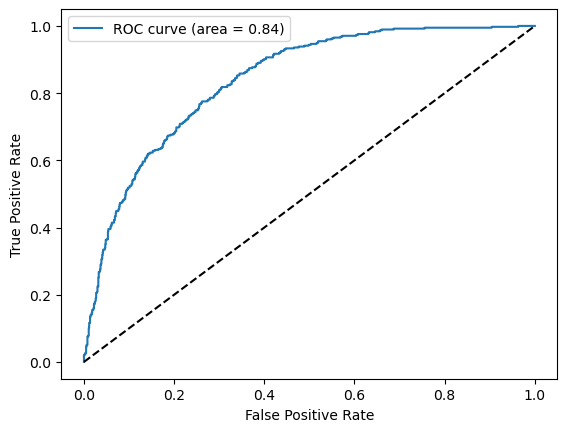

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr,tpr)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--') # Baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

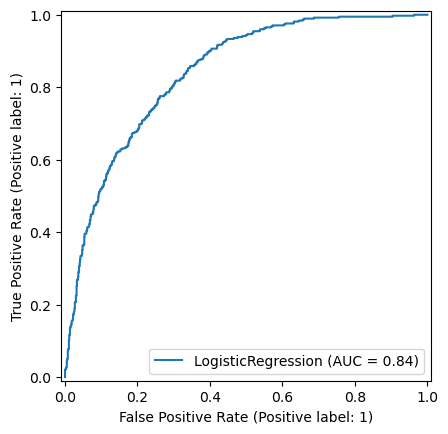

In [27]:
RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.show()

* Our recall has significantly increased but due to this, precision would have been highly impacted.
* To see the impact of precision on all values of threshold and the overall impact we plot the Presicion Recall Curve
* This curve helps us know, at what recall what was our precision


## PRECISION RECALL CURVE

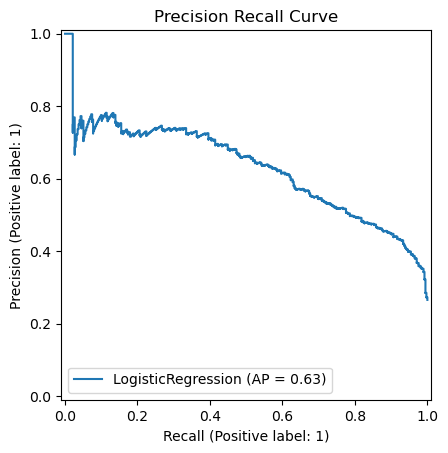

In [28]:
PrecisionRecallDisplay.from_estimator(clf, X_test, y_test)
plt.title("Precision Recall Curve")
plt.show()